In [ ]:


import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ECG BINARY CLASSIFICATION: Normal vs Abnormal")
print("Simplified CNN  ResNet50")
print("="*80)

ECG BINARY CLASSIFICATION: Normal vs Abnormal
Simplified CNN | EfficientNetB0 | ResNet50


In [ ]:
# ============================================================
# الخلية 2: Config - إعدادات المشروع
# ============================================================

class Config:
    DATA_PATH = "/content/clean_data"
    BATCH_SIZE = 16

    FOLDER_MAPPING = {
        'Normal': ['Normal', 'normal'],
        'Abnormal': ['Abnormal', 'abnormal']
    }

In [ ]:
# ============================================================
# الخلية 3: DataLoader - تحميل البيانات
# ============================================================

class DataLoader:
    def __init__(self, class_names, data_path=Config.DATA_PATH):
        self.data_path = data_path
        self.class_names = class_names
        self.df = None

    def find_class_folder(self, base_path, class_name):
        for folder_name in Config.FOLDER_MAPPING.get(class_name, [class_name]):
            folder_path = os.path.join(base_path, folder_name)
            if os.path.exists(folder_path) and os.path.isdir(folder_path):
                return folder_path
        return None

    def load_data(self):
        print("\n[1] LOADING DATASET")
        print("="*60)

        if not os.path.exists(self.data_path):
            alt_paths = [
                "/content/drive/MyDrive/clean_data",
                "/content/clean_data",
                "/content/data/clean_data"
            ]
            for alt in alt_paths:
                if os.path.exists(alt):
                    self.data_path = alt
                    print(f"Using alternative path: {self.data_path}")
                    break
            else:
                raise FileNotFoundError(f"Dataset not found at {self.data_path}")

        paths, labels = [], []
        for idx, class_name in enumerate(self.class_names):
            folder = self.find_class_folder(self.data_path, class_name)
            if folder:
                images = [f for f in os.listdir(folder)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                for img in images:
                    paths.append(os.path.join(folder, img))
                    labels.append(idx)
                print(f"  {class_name}: {len(images)} images")
            else:
                print(f"  {class_name}: folder not found")

        self.df = pd.DataFrame({'path': paths, 'label': labels})
        print(f"\n  Total images: {len(self.df)}")

        for class_name in self.class_names:
            count = len(self.df[self.df['label'] == self.class_names.index(class_name)])
            pct = count / len(self.df) * 100 if len(self.df) > 0 else 0
            print(f"    {class_name}: {count} ({pct:.1f}%)")

        return self.df

In [ ]:
# ============================================================
# الخلية 4: ImagePreprocessor - معالجة الصور
# ============================================================

class ImagePreprocessor:
    def __init__(self, target_size):
        self.target_size = target_size
        self.top_crop = 0.20
        self.bottom_crop = 0.07

    def crop_ecg(self, image):
        h, w = image.shape[:2]
        top = int(h * self.top_crop)
        bottom = int(h * (1 - self.bottom_crop))
        return image[top:bottom, :]

    def apply_median_filter(self, image, kernel_size=3):
        if len(image.shape) == 3:
            filtered = np.zeros_like(image)
            for i in range(3):
                filtered[:, :, i] = cv2.medianBlur(image[:, :, i], kernel_size)
            return filtered
        return cv2.medianBlur(image, kernel_size)

    def apply_clahe(self, image, clip_limit=2.0, tile_grid_size=(8,8)):
        if len(image.shape) == 3:
            lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            l = clahe.apply(l)
            lab_clahe = cv2.merge((l, a, b))
            return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        else:
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            return clahe.apply(image)

    def preprocess(self, image_path):
        img = cv2.imread(image_path)
        if img is None:
            return None

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.crop_ecg(img)
        img = self.apply_median_filter(img, kernel_size=3)
        img = self.apply_clahe(img, clip_limit=2.0, tile_grid_size=(8,8))
        img = cv2.resize(img, self.target_size)
        img = img.astype(np.float32) / 255.0
        return img

In [ ]:
# ============================================================
# الخلية 5: DataAugmentor - زيادة البيانات
# ============================================================

class DataAugmentor:
    @staticmethod
    def augment(image):
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)

        if np.random.random() > 0.5:
            angle = np.random.uniform(-10, 10)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        if np.random.random() > 0.5:
            zoom = np.random.uniform(0.9, 1.1)
            h, w = image.shape[:2]
            new_h, new_w = int(h * zoom), int(w * zoom)

            if zoom > 1:
                start_h, start_w = (new_h - h) // 2, (new_w - w) // 2
                cropped = image[start_h:start_h+h, start_w:start_w+w]
                image = cv2.resize(cropped, (w, h))
            else:
                resized = cv2.resize(image, (new_w, new_h))
                pad_h, pad_w = (h - new_h) // 2, (w - new_w) // 2
                image = np.pad(resized,
                              ((pad_h, h - new_h - pad_h),
                               (pad_w, w - new_w - pad_w), (0, 0)),
                              mode='reflect')

        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.85, 1.15)
            image = np.clip(image * brightness, 0, 1)

        return image

In [ ]:
# ============================================================
# الخلية 6: ECGDataGenerator - مولد البيانات
# ============================================================

class ECGDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, preprocessor, augmentor=None, batch_size=16,
                 shuffle=True, augment=False, num_classes=2):
        self.dataframe = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.augmentor = augmentor
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.num_classes = num_classes
        self.indices = np.arange(len(self.dataframe))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_data = self.dataframe.iloc[batch_indices]

        X, y = [], []
        for _, row in batch_data.iterrows():
            img = self.preprocessor.preprocess(row['path'])
            if img is not None:
                if self.augment and self.augmentor is not None:
                    img = self.augmentor.augment(img)
                X.append(img)
                y.append(row['label'])

        X = np.array(X)
        y = tf.keras.utils.to_categorical(y, num_classes=self.num_classes)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# ============================================================
# الخلية 7: DataSplitter - تقسيم البيانات
# ============================================================

class DataSplitter:
    def __init__(self, df):
        self.df = df

    def split_data(self):
        X = self.df['path'].values
        y = self.df['label'].values

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
        )

        self.train_df = pd.DataFrame({'path': X_train, 'label': y_train})
        self.val_df = pd.DataFrame({'path': X_val, 'label': y_val})
        self.test_df = pd.DataFrame({'path': X_test, 'label': y_test})

        print(f"\n  Split Results:")
        print(f"    Train: {len(self.train_df)} images")
        print(f"    Validation: {len(self.val_df)} images")
        print(f"    Test: {len(self.test_df)} images")

        return self.train_df, self.val_df, self.test_df

In [ ]:
# ============================================================
# الخلية 8: ModelBuilders - بناء النماذج
# ============================================================

class ModelBuilders:
    @staticmethod
    def build_simplified_cnn(input_shape=(128, 128, 3), num_classes=2):
        print("\n  Building Simplified CNN Model")
        print("  " + "-"*40)

        inputs = keras.Input(shape=input_shape)

        x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(32, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Conv2D(64, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.35)(x)

        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.4)(x)

        outputs = layers.Dense(num_classes, activation='softmax')(x)
        model = keras.Model(inputs=inputs, outputs=outputs)

        total_params = model.count_params()
        print(f"    Total Parameters: {total_params:,}")

        return model


    @staticmethod
    def build_resnet50(input_shape=(224, 224, 3), num_classes=2):
        print("\n  Building ResNet50 Model")
        print("  " + "-"*40)

        base_model = tf.keras.applications.ResNet50(
            include_top=False, weights='imagenet', input_shape=input_shape
        )
        base_model.trainable = False

        inputs = keras.Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)

        model = keras.Model(inputs=inputs, outputs=outputs)

        total_params = model.count_params()
        print(f"    Base Model Layers: {len(base_model.layers)}")
        print(f"    Total Parameters: {total_params:,}")

        return model, base_model

In [ ]:
# ============================================================
# الخلية 9: Trainer - التدريب والتقييم
# ============================================================

class Trainer:
    def __init__(self, model, class_weights, experiment_name):
        self.model = model
        self.class_weights = class_weights
        self.experiment_name = experiment_name
        self.history = None
        self.results = None

    def train(self, train_gen, val_gen, epochs=30, fine_tune_epochs=10, use_fine_tune=True):
        print("\n[5] TRAINING MODEL")
        print("="*60)

        print("\n  Class Weights Used:")
        for class_name, weight in zip(['Normal', 'Abnormal'],
                                     [self.class_weights[0], self.class_weights[1]]):
            print(f"    {class_name}: {weight:.3f}")

        # =========================================================
        # PHASE 1: Training
        # =========================================================
        print(f"\n  Phase 1: Training for {epochs} epochs (LR: 1e-3)")

        callbacks_1 = [
            callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
            callbacks.ModelCheckpoint(f'{self.experiment_name}_best.keras',
                                     monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy',
                     keras.metrics.Precision(name='precision'),
                     keras.metrics.Recall(name='recall')]
        )

        history1 = self.model.fit(
            train_gen,
            steps_per_epoch=len(train_gen),
            validation_data=val_gen,
            validation_steps=len(val_gen),
            epochs=epochs,
            class_weight=self.class_weights,
            callbacks=callbacks_1,
            verbose=1
        )

        combined_history = dict(history1.history)

        # =========================================================
        # PHASE 2: Fine-tuning (if applicable)
        # =========================================================
        if use_fine_tune and hasattr(self.model, 'base_model'):
            print(f"\n  Phase 2: Fine-tuning for {fine_tune_epochs} epochs (LR: 1e-5)")

            # Unfreeze top layers
            self.model.base_model.trainable = True
            for layer in self.model.base_model.layers[:100]:
                layer.trainable = False

            trainable_layers = sum([1 for layer in self.model.base_model.layers if layer.trainable])
            print(f"    Trainable Layers: {trainable_layers} out of {len(self.model.base_model.layers)}")

            callbacks_2 = [
                callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
                callbacks.ModelCheckpoint(f'{self.experiment_name}_finetuned.keras',
                                         monitor='val_accuracy', save_best_only=True, verbose=1)
            ]

            self.model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                loss='categorical_crossentropy',
                metrics=['accuracy',
                         keras.metrics.Precision(name='precision'),
                         keras.metrics.Recall(name='recall')]
            )

            history2 = self.model.fit(
                train_gen,
                steps_per_epoch=len(train_gen),
                validation_data=val_gen,
                validation_steps=len(val_gen),
                epochs=fine_tune_epochs,
                class_weight=self.class_weights,
                callbacks=callbacks_2,
                verbose=1
            )

            # Merge histories
            for key in history2.history:
                if key in combined_history:
                    combined_history[key].extend(history2.history[key])
                else:
                    combined_history[key] = history2.history[key]

        self.history = combined_history
        return self.history

    def evaluate(self, test_gen):
        print("\n[6] EVALUATING MODEL")
        print("="*60)

        # Load best model
        try:
            self.model.load_weights(f'{self.experiment_name}_finetuned.keras')
            print("  Loaded fine-tuned model")
        except:
            try:
                self.model.load_weights(f'{self.experiment_name}_best.keras')
                print("  Loaded trained model")
            except:
                print("  Using current model weights")

        loss, accuracy, precision, recall = self.model.evaluate(test_gen, verbose=0)
        print(f"\n  Test Accuracy: {accuracy*100:.2f}%")
        print(f"  Test Loss: {loss:.4f}")

        # Get predictions
        y_true, y_pred, y_pred_proba = [], [], []
        for i in range(len(test_gen)):
            X_batch, y_batch = test_gen[i]
            pred_proba = self.model.predict(X_batch, verbose=0)
            pred = np.argmax(pred_proba, axis=1)
            y_true.extend(np.argmax(y_batch, axis=1))
            y_pred.extend(pred)
            y_pred_proba.extend(pred_proba[:, 1])

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_pred_proba = np.array(y_pred_proba)

        print("\n  Classification Report:")
        print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

        cm = confusion_matrix(y_true, y_pred)
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        print(f"\n  AUC-ROC: {roc_auc:.3f}")

        self.results = {
            'loss': loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'confusion_matrix': cm,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc
        }

        return self.results

In [ ]:
# ============================================================
# الخلية 10: OverfittingAnalyzer - تحليل فرط التخصص
# ============================================================

class OverfittingAnalyzer:
    @staticmethod
    def analyze(history):
        if 'accuracy' not in history or 'val_accuracy' not in history:
            return {'level': 'UNKNOWN', 'gap': 0}

        train_acc = history['accuracy']
        val_acc = history['val_accuracy']
        acc_gap = np.array(train_acc) - np.array(val_acc)
        final_gap = acc_gap[-1] if len(acc_gap) > 0 else 0

        if final_gap > 0.15:
            level, recommendation = "HIGH", "Increase regularization"
        elif final_gap > 0.08:
            level, recommendation = "MEDIUM", "Monitor closely"
        else:
            level, recommendation = "LOW", "Model generalizes well"

        return {
            'level': level,
            'final_gap': final_gap,
            'train_acc': train_acc[-1] if len(train_acc) > 0 else 0,
            'val_acc': val_acc[-1] if len(val_acc) > 0 else 0,
            'recommendation': recommendation
        }

In [ ]:
# ============================================================
# الخلية 11: Visualizer - الرسوم البيانية
# ============================================================

class Visualizer:
    @staticmethod
    def plot_training_history(history, title_prefix=""):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        metrics = ['accuracy', 'loss', 'precision', 'recall']
        titles = ['Accuracy', 'Loss', 'Precision', 'Recall']

        for idx, (metric, title) in enumerate(zip(metrics, titles)):
            row, col = idx // 2, idx % 2
            axes[row, col].plot(history[metric], label='Train', linewidth=2)
            axes[row, col].plot(history[f'val_{metric}'], label='Validation', linewidth=2)
            axes[row, col].set_title(f'{title_prefix} - {title}', fontsize=14, fontweight='bold')
            axes[row, col].set_xlabel('Epoch')
            axes[row, col].set_ylabel(title)
            axes[row, col].legend()
            axes[row, col].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(cm, class_names=['Normal', 'Abnormal'], title_prefix=""):
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{title_prefix} - Confusion Matrix', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_roc_curve(fpr, tpr, roc_auc, title_prefix=""):
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{title_prefix} - ROC Curve', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
# ============================================================
# الخلية 12: ExperimentRunner - تشغيل التجارب
# ============================================================

class ExperimentRunner:
    def __init__(self, model_type, model_builder, input_size, use_fine_tune=True):
        self.model_type = model_type
        self.model_builder = model_builder
        self.input_size = input_size
        self.use_fine_tune = use_fine_tune
        self.results = None
        self.model = None

    def run(self):
        print("\n" + "="*80)
        print(f"EXPERIMENT: {self.model_type}")
        print("Normal vs Abnormal")
        print("="*80)

        # Load data
        loader = DataLoader(['Normal', 'Abnormal'])
        df = loader.load_data()

        # Split data
        splitter = DataSplitter(df)
        train_df, val_df, test_df = splitter.split_data()

        # Preprocessors
        preprocessor = ImagePreprocessor(target_size=self.input_size)
        augmentor = DataAugmentor()

        # Create generators
        train_gen = ECGDataGenerator(train_df, preprocessor, augmentor,
                                     batch_size=Config.BATCH_SIZE,
                                     shuffle=True, augment=True, num_classes=2)
        val_gen = ECGDataGenerator(val_df, preprocessor, None,
                                   batch_size=Config.BATCH_SIZE,
                                   shuffle=False, augment=False, num_classes=2)
        test_gen = ECGDataGenerator(test_df, preprocessor, None,
                                    batch_size=Config.BATCH_SIZE,
                                    shuffle=False, augment=False, num_classes=2)

        print(f"\n  Steps per epoch:")
        print(f"    Train: {len(train_gen)}")
        print(f"    Validation: {len(val_gen)}")
        print(f"    Test: {len(test_gen)}")

        # Calculate class weights
        y_train = train_df['label'].values
        class_weights_list = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = {0: class_weights_list[0], 1: class_weights_list[1]}

        print("\n  Class Weights:")
        print(f"    Normal: {class_weights[0]:.3f}")
        print(f"    Abnormal: {class_weights[1]:.3f}")

        # Build model
        print("\n[4] BUILDING MODEL")
        print("="*60)

        if self.model_type in ['EfficientNetB0', 'ResNet50']:
            model, base_model = self.model_builder(input_shape=(*self.input_size, 3), num_classes=2)
            model.base_model = base_model
        else:
            model = self.model_builder(input_shape=(*self.input_size, 3), num_classes=2)

        # Train
        trainer = Trainer(model, class_weights, self.model_type.lower())
        history = trainer.train(train_gen, val_gen, epochs=30, fine_tune_epochs=10,
                                use_fine_tune=self.use_fine_tune)

        # Evaluate
        results = trainer.evaluate(test_gen)

        # Visualize
        Visualizer.plot_training_history(history, self.model_type)
        Visualizer.plot_confusion_matrix(results['confusion_matrix'], ['Normal', 'Abnormal'], self.model_type)
        Visualizer.plot_roc_curve(results['fpr'], results['tpr'], results['roc_auc'], self.model_type)

        # Overfitting analysis
        overfitting = OverfittingAnalyzer.analyze(history)

        # Print summary
        self._print_summary(results, overfitting)

        # Save model
        model.save(f'{self.model_type.lower()}_ecg_model.keras')
        print(f"\n  Model saved: {self.model_type.lower()}_ecg_model.keras")

        self.results = results
        self.model = model
        return results, model, history

    def _print_summary(self, results, overfitting):
        print("\n" + "="*80)
        print(f"{self.model_type} - FINAL SUMMARY")
        print("="*80)

        acc = results['accuracy'] * 100
        print(f"\n  Test Accuracy: {acc:.2f}%")
        print(f"  Test Precision: {results['precision']:.4f}")
        print(f"  Test Recall: {results['recall']:.4f}")
        print(f"  Test AUC-ROC: {results['roc_auc']:.3f}")

        print("\n  Classification Report:")
        print(classification_report(results['y_true'], results['y_pred'],
                                   target_names=['Normal', 'Abnormal']))

        print(f"\n  Overfitting Analysis:")
        print(f"    Level: {overfitting['level']}")
        print(f"    Accuracy Gap: {overfitting['final_gap']:.4f}")
        print(f"    Train Accuracy: {overfitting['train_acc']*100:.2f}%")
        print(f"    Validation Accuracy: {overfitting['val_acc']*100:.2f}%")

        print("="*80)


STARTING EXPERIMENT 1: SIMPLIFIED CNN

EXPERIMENT: SimplifiedCNN
Normal vs Abnormal

[1] LOADING DATASET
  Normal: 142 images
  Abnormal: 233 images

  Total images: 375
    Normal: 142 (37.9%)
    Abnormal: 233 (62.1%)

  Split Results:
    Train: 262 images
    Validation: 56 images
    Test: 57 images

  Steps per epoch:
    Train: 17
    Validation: 4
    Test: 4

  Class Weights:
    Normal: 1.323
    Abnormal: 0.804

[4] BUILDING MODEL

  Building Simplified CNN Model
  ----------------------------------------
    Total Parameters: 30,338

[5] TRAINING MODEL

  Class Weights Used:
    Normal: 1.323
    Abnormal: 0.804

  Phase 1: Training for 30 epochs (LR: 1e-3)
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5064 - loss: 0.7659 - precision: 0.5064 - recall: 0.5064
Epoch 1: val_accuracy improved from None to 0.62500, saving model to simplifiedcnn_best.keras

Epoch 1: finished saving model to simplifiedcnn_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accura

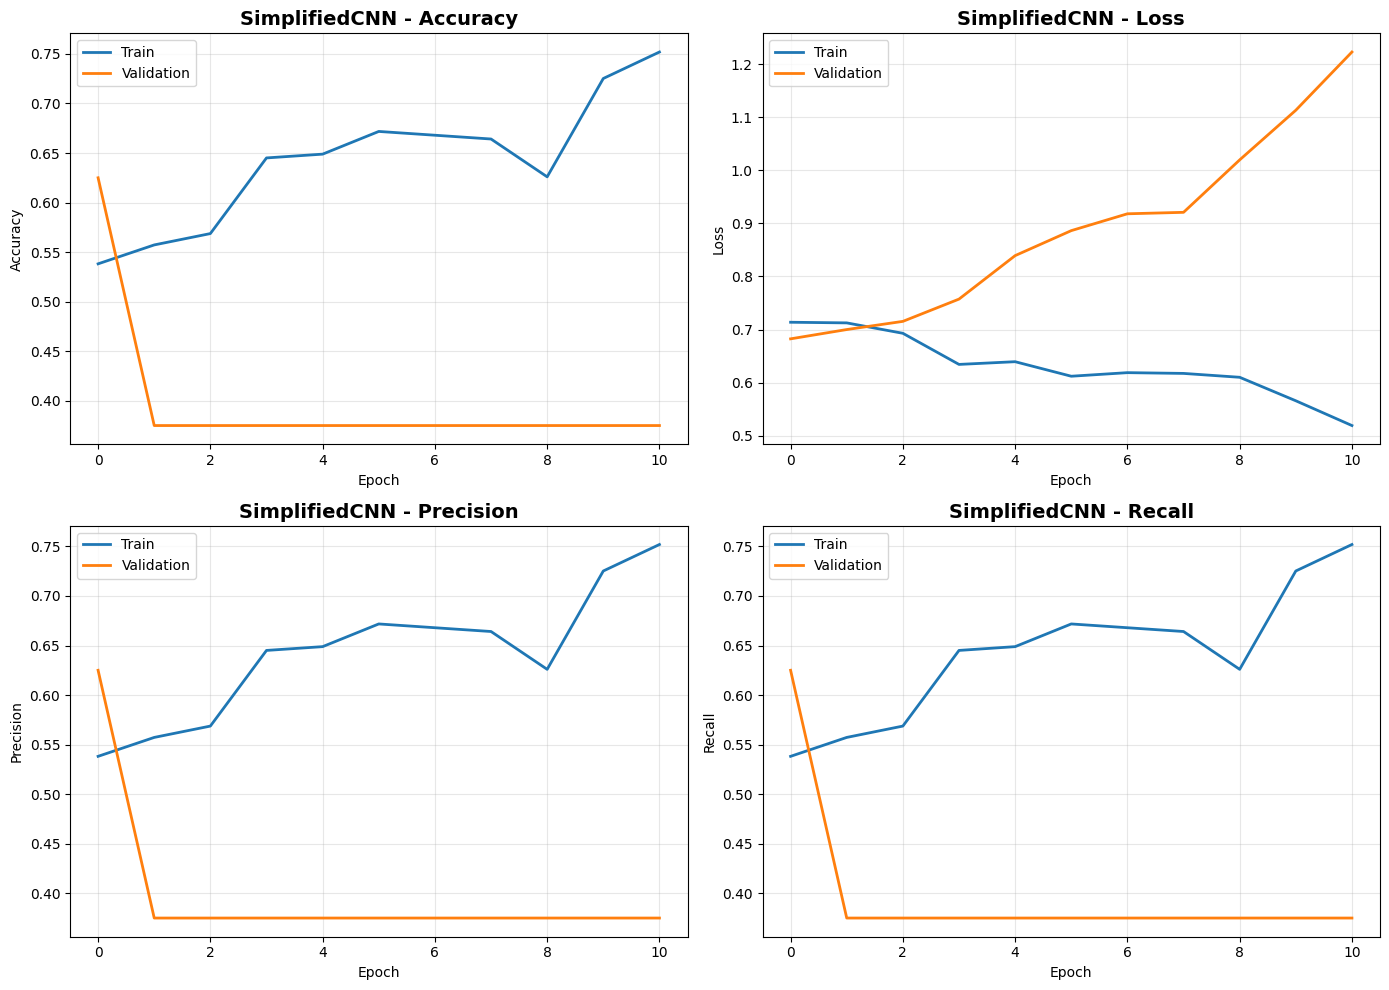

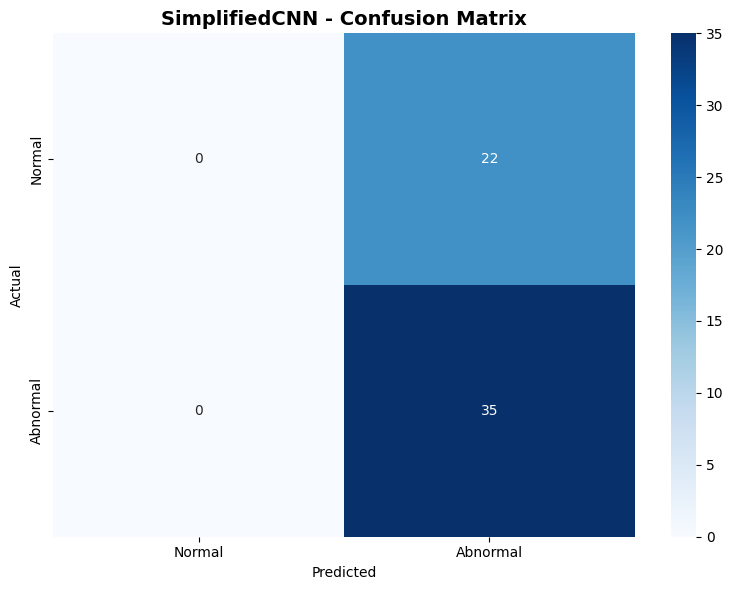

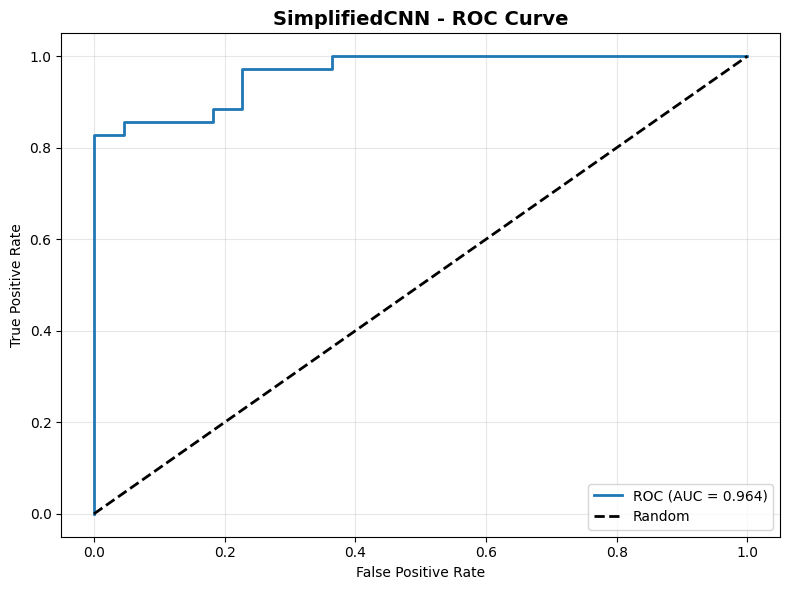


SimplifiedCNN - FINAL SUMMARY

  Test Accuracy: 61.40%
  Test Precision: 0.6140
  Test Recall: 0.6140
  Test AUC-ROC: 0.964

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        22
    Abnormal       0.61      1.00      0.76        35

    accuracy                           0.61        57
   macro avg       0.31      0.50      0.38        57
weighted avg       0.38      0.61      0.47        57


  Overfitting Analysis:
    Level: HIGH
    Accuracy Gap: 0.3769
    Train Accuracy: 75.19%
    Validation Accuracy: 37.50%

  Model saved: simplifiedcnn_ecg_model.keras


In [ ]:
# ============================================================
# الخلية 13: تشغيل Simplified CNN
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 1: SIMPLIFIED CNN")
print("="*80)

exp_cnn = ExperimentRunner(
    model_type="SimplifiedCNN",
    model_builder=ModelBuilders.build_simplified_cnn,
    input_size=(128, 128),
    use_fine_tune=False
)
results_cnn, model_cnn, history_cnn = exp_cnn.run()


STARTING EXPERIMENT 3: RESNET50

EXPERIMENT: ResNet50
Normal vs Abnormal

[1] LOADING DATASET
  Normal: 142 images
  Abnormal: 233 images

  Total images: 375
    Normal: 142 (37.9%)
    Abnormal: 233 (62.1%)

  Split Results:
    Train: 262 images
    Validation: 56 images
    Test: 57 images

  Steps per epoch:
    Train: 17
    Validation: 4
    Test: 4

  Class Weights:
    Normal: 1.323
    Abnormal: 0.804

[4] BUILDING MODEL

  Building ResNet50 Model
  ----------------------------------------
    Base Model Layers: 175
    Total Parameters: 23,859,138

[5] TRAINING MODEL

  Class Weights Used:
    Normal: 1.323
    Abnormal: 0.804

  Phase 1: Training for 30 epochs (LR: 1e-3)
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4642 - loss: 1.1932 - precision: 0.4642 - recall: 0.4642
Epoch 1: val_accuracy improved from None to 0.62500, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 110s 6s/step - a

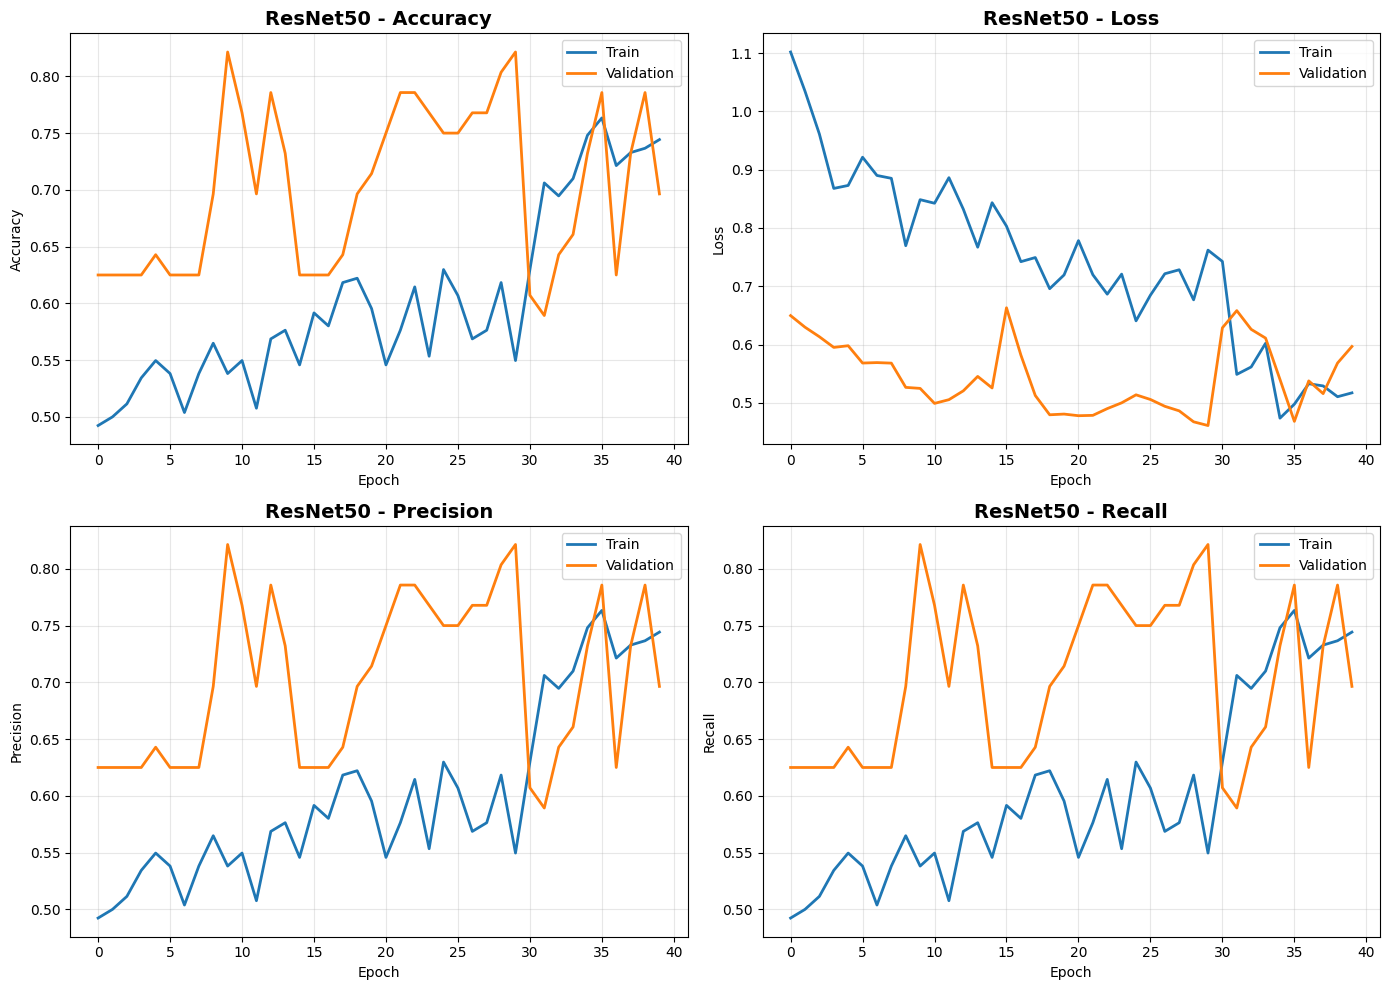

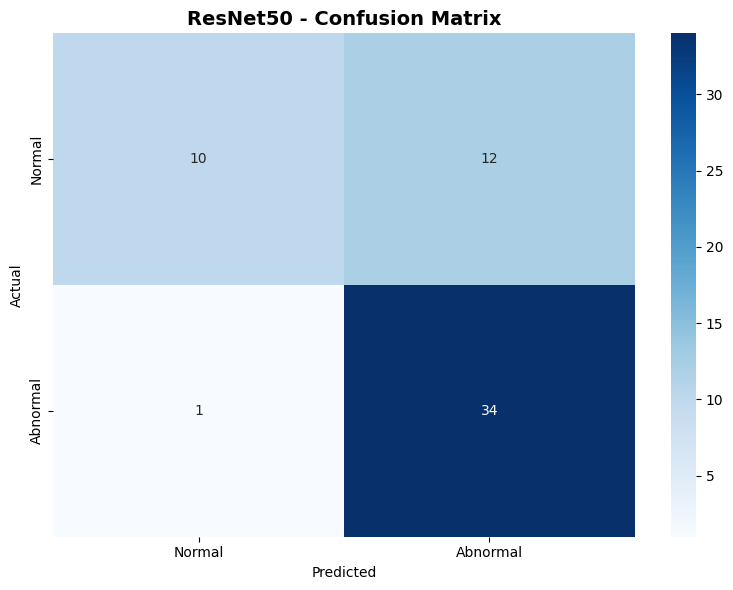

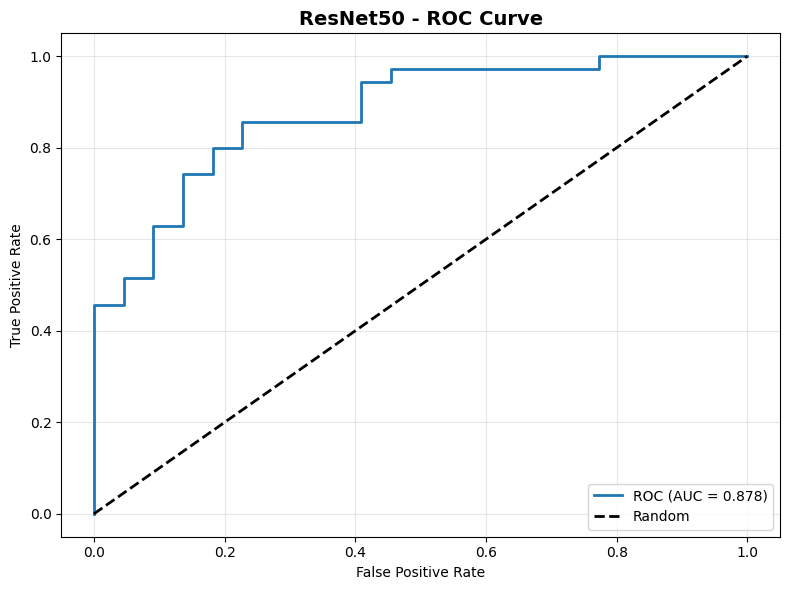


ResNet50 - FINAL SUMMARY

  Test Accuracy: 77.19%
  Test Precision: 0.7719
  Test Recall: 0.7719
  Test AUC-ROC: 0.878

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.45      0.61        22
    Abnormal       0.74      0.97      0.84        35

    accuracy                           0.77        57
   macro avg       0.82      0.71      0.72        57
weighted avg       0.80      0.77      0.75        57


  Overfitting Analysis:
    Level: LOW
    Accuracy Gap: 0.0478
    Train Accuracy: 74.43%
    Validation Accuracy: 69.64%

  Model saved: resnet50_ecg_model.keras


In [ ]:
# ============================================================
# الخلية 15: تشغيل ResNet50
# ============================================================

print("\n" + "="*80)
print("STARTING EXPERIMENT 3: RESNET50")
print("="*80)

exp_resnet = ExperimentRunner(
    model_type="ResNet50",
    model_builder=ModelBuilders.build_resnet50,
    input_size=(224, 224),
    use_fine_tune=True
)
results_resnet, model_resnet, history_resnet = exp_resnet.run()